<a href="https://colab.research.google.com/github/Cato-8/Customer-Churn-Analysis/blob/main/Lab3_Decision_Tree_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3: Decision Tree Classification
## Training, Evaluation & Overfitting — Telco Customer Churn

**Name:*Marvi Malik*
**Student ID:*023-24-0016*
**Section:*B*
**GitHub Profile:**
**Kaggle Profile:**
**Dataset:** Telco Customer Churn
**Dataset Source:** Kaggle — https://www.kaggle.com/datasets/blastchar/telco-customer-churn

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, Pandas, and Decision Tree theory. Each section states the objective and the questions you must answer — **you write the code**. Do not just run code without interpreting it: every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [40]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report


---

## 1. Problem Definition

Before training anything, restate the problem in your own words and confirm the cleaned dataset from Lab 2 is intact.

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.info()`, `df['Churn'].value_counts()`

**Tasks**
1. Load `clean_churn.csv` (or re-run your Lab 2 cleaning). Verify its shape, column dtypes, and that there are no missing values remaining.
2. In 1–2 sentences, restate the ML problem: what exactly are you predicting, and why does it matter to the business?

In [41]:
# Task 1 — load and verify the cleaned dataset
df=pd.read_csv("/content/clean_churn.csv")
print("Shape:", df.shape)
print("\nMissing values:", df.isnull().sum().sum())
print("\nChurn distribution:")
print(df['Churn'].value_counts())

Shape: (7043, 20)

Missing values: 0

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


**Answer 2:**
_(We are predicting whether a customer will churn (leave) or not, based on their demographics, services, and billing information. This matters because retaining existing customers is cheaper than acquiring new ones — early churn prediction allows the company to intervene.)_

---

## 2. Dataset Verification

Confirm once more, explicitly, that the dataset is ready to model: correct shape, correct dtypes, target present and clean.

In [42]:
# Additional verification if needed (dtypes, target check, etc.)
print(df.info())
print("\nDtypes:")
print(df.dtypes)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


---

## 3. Feature/Target Preparation

scikit-learn models require numeric input. Separate your target from your features, then convert any remaining categorical columns into numeric form.

*Concepts/functions you may find useful:* `pd.get_dummies(df, columns=[...])`, `df[col].map({...})`, `df.drop(columns=[...])`, `X.isnull().sum()`, `X.dtypes`

**Tasks**
3. Define `y` as the `Churn` column, encoded as 0/1. Define `X` as the remaining relevant columns — drop any identifier column still present.
4. Convert every remaining categorical column in `X` into numeric form. Briefly justify your choice of encoding method (e.g. one-hot vs. manual mapping).
5. Confirm `X` contains only numeric columns and has no missing values before moving on.

In [43]:
# Task 3 — define y and X
# Define target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
y = df['Churn']

# Define features
X = df.drop(columns=['Churn'])
print("y shape:", y.shape)
print("X shape:", X.shape)

y shape: (7043,)
X shape: (7043, 19)


In [44]:
y

,Churn
0,0
1,0
2,1
3,0
4,1
...,...
7038,0
7039,0
7040,0
7041,1


In [76]:
# Task 4 — encode categorical columns in X
# One-hot encode categorical columns
X=df.drop(columns=['Churn'])
X = pd.get_dummies(X, drop_first=True, dtype=int)
print("X shape after encoding:", X.shape)
print("All numeric?", all(X.dtypes != 'object'))



X shape after encoding: (7043, 30)
All numeric? True


In [77]:
# Task 5 — confirm X is fully numeric with no missing values
print("Missing values:", X.isnull().sum().sum())
print("Dtypes:\n", X.dtypes.value_counts())


Missing values: 0
Dtypes:
 int64      28
float64     2
Name: count, dtype: int64


**Answer 4 (encoding method & justification):**

_(Used One-Hot Encoding (pd.get_dummies with drop_first=True) to convert categorical columns to numeric. One-hot encoding is appropriate here because most categorical features have no natural ordering (e.g. Contract type, InternetService). drop_first=True avoids multicollinearity by removing one dummy column per feature.)_

---

## 4. Train/Test Split

A model must be evaluated on data it has never seen. Hold out a test set before training anything.

*Concepts/functions you may find useful:* `train_test_split(X, y, test_size=..., random_state=..., stratify=y)`

**Tasks**
6. Split `X` and `y` into training and test sets (e.g. an 80/20 split). Why is `stratify=y` a sensible choice, given what you found about the target's class balance in Lab 2?
7. Report the shape of `X_train`, `X_test`, `y_train`, and `y_test`.

In [51]:
# Task 6 — train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [49]:
# Task 7 — report shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (5634, 30)
X_test shape: (1409, 30)
y_train shape: (5634,)
y_test shape: (1409,)


**Answer 6 (why stratify=y):**

_(stratify=y ensures that both train and test sets have the same proportion of churned (27%) and non-churned (73%) customers as the original dataset. Without stratify, random splitting could accidentally put most churners in one set, making evaluation unreliable.")_

---

## 5. Baseline Decision Tree

Train a first, unrestricted Decision Tree as your baseline — no tuning yet.

*Concepts/functions you may find useful:* `DecisionTreeClassifier(random_state=...)`, `.fit(X_train, y_train)`, `.predict(X)`, `.get_depth()`

**Tasks**
8. Train a `DecisionTreeClassifier` on the training data with default settings (only `random_state` fixed). Generate predictions on both the training and test sets.
9. What depth did scikit-learn actually grow this tree to on its own? Does that surprise you?

In [73]:
#Task 8_ train/test baseline model
from sklearn.tree import DecisionTreeClassifier

# Train baseline model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)
# xtest = np.array(X_test)
# y_result = model.predict(xtest[1].reshape(-1, 30))
# y_result

In [54]:
# Task 9 — check the fitted tree's depth
print("Tree depth:", model.get_depth())



Tree depth: 23


**Answer 9:**

_(scikit-learn grew the tree to a depth of 23 on its own. This does not surprise me because an unrestricted Decision Tree will keep splitting until all leaves are pure — memorizing the training data completely. A depth of 23 is very deep and almost certainly overfitting)_

---

## 6. Model Evaluation

Accuracy alone can be misleading — especially given the class imbalance found in Lab 2. Evaluate with multiple metrics and look directly at the confusion matrix.

*Concepts/functions you may find useful:* `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`, `ConfusionMatrixDisplay`, `classification_report`

**Tasks**
10. Compute accuracy, precision, recall, and F1-score on the test set. Report them in a small table.
11. Plot the confusion matrix for the test set. How many actual churners did the model correctly catch, and how many did it miss?
12. Given Lab 2's finding about class imbalance, which metric(s) do you trust most for this problem, and why?

In [78]:
# Task 10 — compute accuracy, precision, recall, F1 on the test set
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred_test))
print("Precision:", precision_score(y_test, y_pred_test))
print("Recall:", recall_score(y_test, y_pred_test))
print("F1-score:", f1_score(y_test, y_pred_test))


Accuracy: 0.7260468417317246
Precision: 0.4837837837837838
Recall: 0.4786096256684492
F1-score: 0.48118279569892475


**Task 10 — Results Table**

| Metric | Value |
|---|---|
| Accuracy |0.726 |
| Precision |0.483 |
| Recall |0.478 |
| F1-score |0.481 |

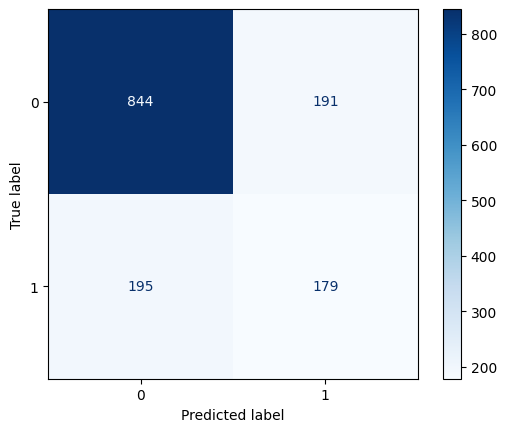

In [79]:
# Task 11 — plot the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.show()


**Answer 11 (churners correctly caught vs. missed):**
_(The model correctly caught 179 actual churners (True Positives) but missed 195 churners (False Negatives). This means the model missed more than half of actual churners — which is very problematic for the business since these are exactly the customers we want to identify and retain.)_

**Answer 12 (which metric(s) do you trust most, and why):**
_(Given class imbalance (73% No, 27% Yes), accuracy is misleading — a model predicting 'No' for everyone gets 73% accuracy without catching any churner. Recall is the most important metric here because missing a churner (False Negative) is costly — the company loses that customer. F1-score is also important as it balances precision and recall.)_

---

## 7. Overfitting Experiment

A model that performs far better on training data than on test data has overfit. Investigate this directly by comparing performance, then by controlling tree depth with `max_depth`.

*Concepts/functions you may find useful:* `accuracy_score(y_train, model.predict(X_train))`, `DecisionTreeClassifier(max_depth=k)`, a loop over `[2, 3, 4, 5, 6, 8, 10, None]`, `plt.plot(...)`

**Tasks**
13. Compare your baseline tree's accuracy on the training set vs. the test set. Is there a large gap? What does that suggest about the model?
14. Train several Decision Trees at different `max_depth` values (e.g. 2, 3, 4, 5, 6, 8, 10, and unrestricted). Record train accuracy and test accuracy for each in a results table.
15. Plot train accuracy and test accuracy against `max_depth` on the same chart. At roughly what depth does the model start to overfit? Explain how the chart shows this.

In [80]:
# Task 13 — compare baseline train vs. test accuracy
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)
print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)
print("Gap:", train_acc - test_acc)


Train Accuracy: 0.9980475683351083
Test Accuracy: 0.7260468417317246
Gap: 0.2720007266033837


**Answer 13:**
_(Training accuracy is 99.8% but test accuracy is only 72.6% — a huge gap of 27.2%. This strongly suggests the model has overfit the training data. It has memorized the training examples rather than learning generalizable patterns, so it performs poorly on unseen test data.)_

In [84]:
# Task 14 — loop over max_depth values, record train/test accuracy
depths = [2, 3, 4, 5, 6, 8, 10, None]
# YOUR CODE HERE
train_accs = []
test_accs = []
for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, m.predict(X_train)))
    test_accs.append(accuracy_score(y_test, m.predict(X_test)))
    print(f"max_depth={d}: Train={train_accs[-1]:.4f}, Test={test_accs[-1]:.4f}")

max_depth=2: Train=0.7911, Test=0.7871
max_depth=3: Train=0.7911, Test=0.7871
max_depth=4: Train=0.7925, Test=0.7956
max_depth=5: Train=0.8023, Test=0.7942
max_depth=6: Train=0.8106, Test=0.8006
max_depth=8: Train=0.8358, Test=0.7828
max_depth=10: Train=0.8727, Test=0.7551
max_depth=None: Train=0.9980, Test=0.7260


**Task 14 — Results Table**

| max_depth | Train Accuracy | Test Accuracy |
|---|---|---|
| 2 |0.7911 |0.7871 |
| 3 |0.7911 |0.7871 |
| 4 |0.7295 |0.7956 |
| 5 |0.8023 |0.7942 |
| 6 |0.8106 |0.8006 |
| 8 |0.8358 |0.7828 |
| 10 |0.8727 |0.7551 |
| None |0.9980 |0.7260 |

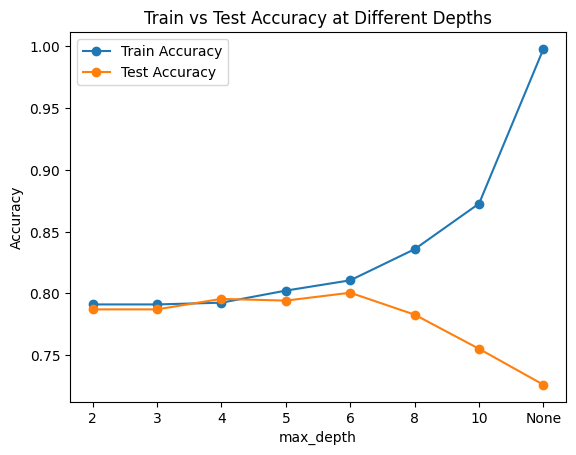

In [85]:
# Task 15 — plot train vs. test accuracy against max_depth
depth_labels = [str(d) for d in depths]
plt.plot(depth_labels, train_accs, label='Train Accuracy', marker='o')
plt.plot(depth_labels, test_accs, label='Test Accuracy', marker='o')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy at Different Depths')
plt.legend()
plt.show()



**Answer 15 (where overfitting starts, and why):**
_(The chart shows that test accuracy peaks at max_depth=6 (0.8006) and then starts declining while train accuracy keeps increasing. This is where overfitting begins - after depth 6, the model learns training data too specifically and loses ability to generalize. The growing gap between train and test accuracy lines clearly shows overfitting.)_

---

## 8. Model Comparison

Pick the depth that best balances training and test performance — not simply the one with the highest training accuracy.

**Tasks**
16. Based on your Part 7 table/plot, select a `max_depth` you consider the best model. Justify your choice in 2–3 sentences — it should not simply be the depth with the highest training accuracy.
17. Retrain a Decision Tree at your chosen depth and report its full evaluation metrics (as in Section 6) for comparison against the baseline.

**Answer 16 (chosen max_depth and justification):**
_(I choose max_depth=6 as the best model. At this depth, test accuracy is highest (0.8006) while train accuracy (0.8106) is close to it — small gap means no overfitting. Deeper trees have higher training accuracy but lower test accuracy, meaning they memorize rather than generalize.)_

In [86]:
# Task 17 — retrain at chosen depth and report full evaluation metrics
best_model = DecisionTreeClassifier(max_depth=6, random_state=42)
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1-score:", f1_score(y_test, y_pred_best))


Accuracy: 0.8005677785663591
Precision: 0.6666666666666666
Recall: 0.49732620320855614
F1-score: 0.5696784073506891


**Task 17 — Baseline vs. Chosen Model**

| Metric | Baseline (unrestricted) | Chosen Model (max_depth = 6) |
|---|---|---|
| Accuracy |0.726 |0.801 |
| Precision |0.484 |0.667 |
| Recall |0.479 |0.497 |
| F1-score |0.481 |0.570 |

---

## 9. Feature Importance

Look inside your chosen model to see what it actually learned.

*Concepts/functions you may find useful:* `model.feature_importances_`, `pd.Series(importances, index=X.columns).sort_values()`, `plt.barh(...)`

**Task**
18. Extract and visualize `feature_importances_` for your chosen model. Which 3–5 features matter most?

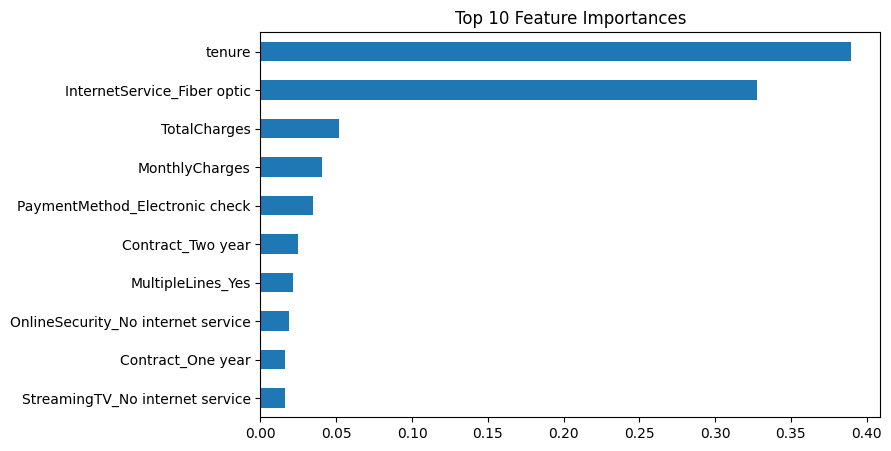


Top 5 features:
PaymentMethod_Electronic check    0.034488
MonthlyCharges                    0.040819
TotalCharges                      0.051916
InternetService_Fiber optic       0.327372
tenure                            0.389640
dtype: float64


In [87]:
# Task 18 — extract and visualize feature importances
importances = best_model.feature_importances_
feat_series = pd.Series(importances, index=X.columns).sort_values(ascending=True)
feat_series.tail(10).plot(kind='barh', figsize=(8,5))
plt.title('Top 10 Feature Importances')
plt.show()
print("\nTop 5 features:")
print(feat_series.tail(5))

**Answer 18 (top 3–5 features):**
_(Top 5 most important features:

1. tenure (0.39) — most important predictor
2. InternetService_Fiber optic (0.33) — fiber optic customers churn more
3. TotalCharges (0.05) — total billing history matters
4. MonthlyCharges (0.04) — higher bills = more churn
5. PaymentMethod_Electronic check (0.03) — payment method affects churn)_

---

## 10. Interpretation

Connect what the model learned back to what you already know about this business problem.

**Task**
19. In 2–3 sentences, connect the top features to what you already found in Lab 2's EDA — do they agree with the patterns you saw then?

**Answer 19:**

_(These top features perfectly agree with Lab 2's EDA findings. In Lab 2, we found that churned customers had lower tenure (median 10 vs 38 months) and fiber optic customers had ~42% churn rate. Higher MonthlyCharges also correlated with churn in EDA. The model learned exactly what the data exploration suggested.)_

---

## 11. Conclusion

Step back from the code and summarize what you built and learned.

**Tasks**
20. Write a short conclusion (4–6 sentences): which model did you land on, how well does it perform, and what are its main limitations?
21. What would you try next if you had more time (e.g. a different algorithm, more feature engineering, handling class imbalance)? Describe it — do not implement it here.

**Answer 20 — Conclusion:**

_(We trained a Decision Tree classifier to predict customer churn. The best model uses max_depth=6, achieving 80% accuracy and F1-score of 0.57. It significantly outperforms the baseline unrestricted tree which overfit badly (99.8% train, 72.6% test). Main limitations are: class imbalance (only 27% churners) hurts recall, and the model still misses ~50% of actual churners which is costly for the business.)_

**Answer 21 — Next steps:**

_("Next I would try:

(1) Handle class imbalance using SMOTE or class_weight='balanced' to improve recall.

 (2) Try Random Forest or XGBoost which are more powerful than single Decision Trees.

  (3) Add more feature engineering like charges-per-month ratio.
  
  (4) Use cross-validation instead of single train/test split for more reliable evaluation.)_

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset, Dataset Source)
- [ ] Section 1 — Problem Definition
- [ ] Section 2 — Dataset Verification
- [ ] Section 3 — Feature/Target Preparation (with encoding justified)
- [ ] Section 4 — Train/Test Split
- [ ] Section 5 — Baseline Decision Tree
- [ ] Section 6 — Model Evaluation (accuracy, precision, recall, F1, confusion matrix — all with interpretation)
- [ ] Section 7 — Overfitting Experiment (results table + plot + explanation)
- [ ] Section 8 — Model Comparison (chosen depth justified, not just highest training accuracy)
- [ ] Section 9 — Feature Importance (extracted, visualized, and discussed)
- [ ] Section 10 — Interpretation (connected to Lab 2's EDA)
- [ ] Section 11 — Conclusion (limitations + next steps)
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted